In [349]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [350]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

import utils

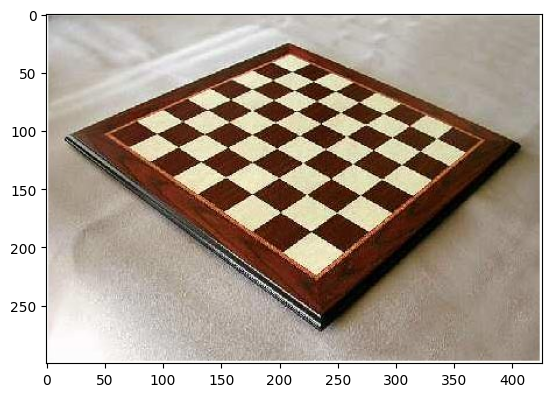

In [351]:
# Loading original image.
feature: str = "chess1"
image_path: str = f"data/q1/{feature}.jpg"

img: np.ndarray = cv.imread(image_path, cv.IMREAD_COLOR_RGB)
plt.imshow(img)
plt.show()

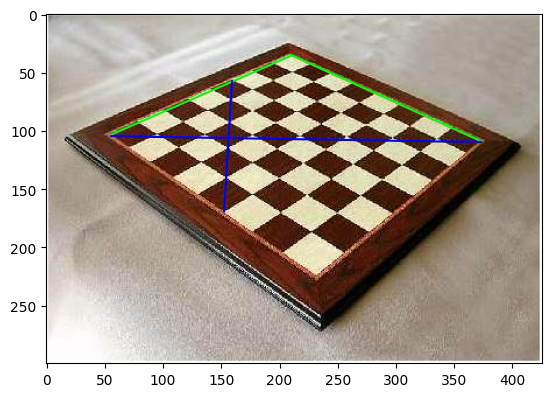

In [352]:
# Read the perpendicular annotations.
i: int = 8

perp_points: np.ndarray = utils.read_annotations(
    "data/annotation/q2_annotation.npy",
    feature,
)

# Draw annotated image.
plt.imshow(img)
plt.plot(perp_points[i:i + 2, 0], perp_points[i:i + 2, 1], c="#0F0")
plt.plot(perp_points[i + 2:i + 4, 0], perp_points[i + 2:i + 4, 1], c="#0F0")
plt.plot(perp_points[i + 4:i + 6, 0], perp_points[i + 4:i + 6, 1], c="#00F")
plt.plot(perp_points[i + 6:i + 8, 0], perp_points[i + 6:i + 8, 1], c="#00F")
plt.show()

In [353]:
# Read the parallel annotations.
par_points: np.ndarray = utils.read_annotations(
    "data/annotation/q1_annotation.npy",
    feature,
)

# Perform affine rectification.
affine_h: np.ndarray = utils.affine_rectification(par_points)

# Computing affinely rectified image and lines.
affine_img: np.ndarray = utils.warp(img, affine_h)
affp_points: np.ndarray = utils.normalize(perp_points @ affine_h.T)

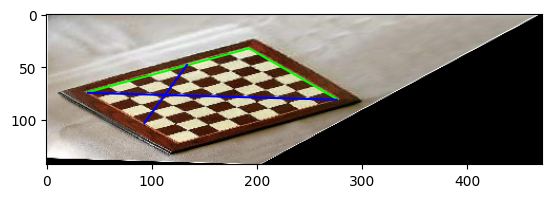

In [354]:
# Draw affinely rectified annotated image.
plt.imshow(affine_img)
plt.plot(affp_points[i:i + 2, 0], affp_points[i:i + 2, 1], c="#0F0")
plt.plot(affp_points[i + 2:i + 4, 0], affp_points[i + 2:i + 4, 1], c="#0F0")
plt.plot(affp_points[i + 4:i + 6, 0], affp_points[i + 4:i + 6, 1], c="#00F")
plt.plot(affp_points[i + 6:i + 8, 0], affp_points[i + 6:i + 8, 1], c="#00F")
plt.show()

In [355]:
# Compute perpendicular lines.
perp_lines: np.ndarray = utils.get_lines(affp_points)
l1, l2, m1, m2 = perp_lines[(i // 2):(i // 2) + 4]

a: np.ndarray = np.array(
    [
        [l1[0] * l2[0], l1[0] * l2[1] + l1[1] * l2[0]],
        [m1[0] * m2[0], m1[0] * m2[1] + m1[1] * m2[0]],
    ]
)

s = np.linalg.inv(a) @ np.array([[-l1[1] * l2[1]], [-m1[1] * m2[1]]])
s = s[:, 0]
s = np.array([[s[0], s[1]], [s[1], 1]])
a = np.linalg.cholesky(s)

metric_h: np.ndarray = np.eye(3)
metric_h[:2, :2] = np.linalg.inv(a)

# Pretty printing.
metric_h

array([[0.367075  , 0.        , 0.        ],
       [0.07393238, 1.02008126, 0.        ],
       [0.        , 0.        , 1.        ]])

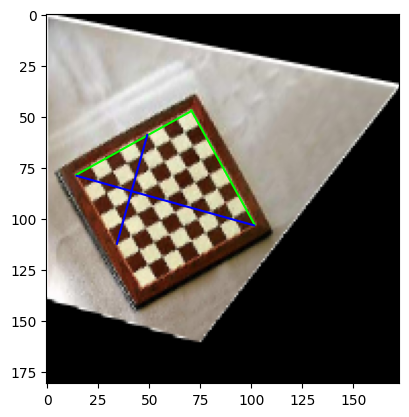

In [356]:
# Computing affinely rectified image and lines.
metric_img: np.ndarray = utils.warp(affine_img, metric_h)
met_points: np.ndarray = utils.normalize(affp_points @ metric_h.T)

# Draw metric rectified annotated image.
plt.imshow(metric_img)
plt.plot(met_points[i + 0:i + 2, 0], met_points[i + 0:i + 2, 1], c="#0F0")
plt.plot(met_points[i + 2:i + 4, 0], met_points[i + 2:i + 4, 1], c="#0F0")
plt.plot(met_points[i + 4:i + 6, 0], met_points[i + 4:i + 6, 1], c="#00F")
plt.plot(met_points[i + 6:i + 8, 0], met_points[i + 6:i + 8, 1], c="#00F")
plt.show()

In [357]:
# Testing parallelism.
h_inv: np.ndarray = np.linalg.inv(metric_h)
ha_inv: np.ndarray = np.linalg.inv(affine_h)

cosines: list[float] = []
for j in range(0, len(perp_points), 4):
    l1: np.ndarray = utils.cross(perp_points[j], perp_points[j + 1])
    l2: np.ndarray = utils.cross(perp_points[j + 2], perp_points[j + 3])
    l1a = ha_inv.T @ l1
    l2a = ha_inv.T @ l2
    l1_prime: np.ndarray = h_inv.T @ l1a
    l2_prime: np.ndarray = h_inv.T @ l2a
    cosines.append((utils.cosine(l1, l2), utils.cosine(l1_prime, l2_prime)))

# Pretty printing.
np.array(cosines)

array([[-1.43023574e-01, -9.65666389e-03],
       [ 2.85019994e-01,  2.10386800e-02],
       [-6.68588141e-01, -3.19840872e-16],
       [ 4.47952139e-02,  9.24626592e-17]])